# EXPLORATORY DATA ANALYSIS OF BREAST CANCER (METABRIC DATASET)

## INTRODUCTION: 
Breast Cancer is one of the most prevalent cancers worldwide and a leading cause of mortality among women. With the advancement of high-throughput technologies, large-scale datasets combining clinical and genomic information have become available.

An exploratory data analysis on the METABRIC - Molecular Taxonomy of Breast Cancer International Consortium dataset to identify patterns and relationships between clinical features and gene expression profiles. The aim is to realize potential factors influencing patient survival and disease progression. 

## OBJECTIVES:
- To explore the distribution and characteristics of key clinical variables in breast cancer patients
- To analyze the relationship between tumor features and patient survival outcomes
- To investigate patterns in gene expression data and their potential association with prognosis
- To identify clinically relevant variables that may influence disease progression and survival

## DATA DESCRIPTION: 
The dataset used is the METABRIC dataset obtained from Kaggle. It contains detailed information on breast cancer patients, including clinical, pathological and genomic information. It enables an integrated analysis of clinical and molecular features.

## DATA OVERVIEW: 
In this section, the structure of the dataset was explored.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import f_oneway

In [2]:
df = pd.read_csv("Breast_Cancer_Gene_expression/data/METABRIC_RNA_Mutation.csv")
df.head()

C:\Users\jasvi\AppData\Local\Temp\ipykernel_21856\3758276581.py:1: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Breast_Cancer_Gene_expression/data/METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(1904, 693)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(4), str(186)
memory usage: 10.1+ MB


In [5]:
df.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03
mean,3921.982143,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,...,4.726891e-07,-3.676471e-07,-9.453782e-07,-1.050420e-07,-0.000002,3.676471e-07,4.726891e-07,7.878151e-07,0.000000,3.731842e-18
std,2358.478332,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,...,1.000263e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000262,1.000264e+00,1.000262e+00,1.000263e+00,1.000262,1.000262e+00
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,-2.120800e+00,-3.364800e+00,-2.719400e+00,-4.982700e+00,-2.981700,-3.833300e+00,-3.609300e+00,-1.166900e+00,-2.112600,-1.051600e+00
25%,896.500000,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,...,-6.188500e-01,-6.104750e-01,-6.741750e-01,-6.136750e-01,-0.632900,-6.664750e-01,-7.102000e-01,-5.058250e-01,-0.476200,-7.260000e-01
50%,4730.500000,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,...,-2.456500e-01,-4.690000e-02,-1.422500e-01,-5.175000e-02,-0.026650,7.000000e-04,-2.980000e-02,-2.885500e-01,-0.133400,-4.248000e-01
75%,5536.250000,70.592500,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.040250,184.716667,...,3.306000e-01,5.144500e-01,5.146000e-01,5.787750e-01,0.590350,6.429000e-01,5.957250e-01,6.022500e-02,0.270375,4.284000e-01
max,7299.000000,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,355.200000,...,6.534900e+00,1.027030e+01,6.329000e+00,4.571300e+00,12.742300,3.938800e+00,3.833400e+00,1.088490e+01,12.643900,3.284400e+00


In [6]:
df.columns

Index(['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
       'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy',
       'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc',
       ...
       'mtap_mut', 'ppp2cb_mut', 'smarcd1_mut', 'nras_mut', 'ndfip1_mut',
       'hras_mut', 'prps2_mut', 'smarcb1_mut', 'stmn2_mut', 'siah1_mut'],
      dtype='str', length=693)

## UNDERSTANDING CLINICAL FEATURES

In [7]:
df.columns[:50]

Index(['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
       'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy',
       'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc',
       'er_status', 'neoplasm_histologic_grade',
       'her2_status_measured_by_snp6', 'her2_status',
       'tumor_other_histologic_subtype', 'hormone_therapy',
       'inferred_menopausal_state', 'integrative_cluster',
       'primary_tumor_laterality', 'lymph_nodes_examined_positive',
       'mutation_count', 'nottingham_prognostic_index', 'oncotree_code',
       'overall_survival_months', 'overall_survival', 'pr_status',
       'radio_therapy', '3-gene_classifier_subtype', 'tumor_size',
       'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten',
       'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1',
       'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d'],
      dtype='str')

This dataset includes 31 clinical attributes, m-RNA levels z-score for 331 genes, and mutation in 175 genes for 1904 breast cancer patients.

The following table summarizes key clinical features, their data types, and their biological or clinical significance.

In [8]:
import pandas as pd

data = [
["patient_id","Object","Unique identifier for each patient"],
["age_at_diagnosis","Float","Age of the patient at diagnosis"],
["type_of_breast_surgery","Object","Type of surgery (Mastectomy or Breast Conserving)"],
["cancer_type","Object","General category of cancer"],
["cancer_type_detailed","Object","Detailed subtype of breast cancer"],
["cellularity","Object","Density and arrangement of tumor cells post-treatment"],
["chemotherapy","Int","Whether chemotherapy was administered (0 = No, 1 = Yes)"],
["pam50_+_claudin-low_subtype","Object","Molecular subtype classification based on gene expression profiling"],
["cohort","Float","Grouping of patients into study cohorts (1–5)"],
["er_status_measured_by_ihc","Object","Estrogen receptor status measured using immunohistochemistry"],
["er_status","Object","Estrogen receptor positivity status"],
["neoplasm_histologic_grade","Float","Tumor grade indicating differentiation level (higher = more aggressive)"],
["her2_status_measured_by_snp6","Object","HER2 status determined using SNP6 genomic analysis"],
["her2_status","Object","HER2 receptor status (positive/negative)"],
["tumor_other_histologic_subtype","Object","Additional histological classification of tumor"],
["hormone_therapy","Int","Whether hormone therapy was given"],
["inferred_menopausal_state","Object","Menopausal status of the patient (pre/post)"],
["integrative_cluster","Object","Molecular subtype classification integrating genomic data"],
["primary_tumor_laterality","Object","Side of the body where tumor is located (left/right)"],
["lymph_nodes_examined_positive","Float","Number of lymph nodes found to contain cancer"],
["mutation_count","Float","Total number of mutations detected in tumor"],
["nottingham_prognostic_index","Float","Prognostic score combining tumor size, grade, and lymph node status"],
["oncotree_code","Object","Standardized cancer classification code"],
["overall_survival_months","Float","Survival duration in months"],
["overall_survival","Int","Binary survival outcome (1 = survived, 0 = not survived)"],
["pr_status","Object","Progesterone receptor status"],
["radio_therapy","Int","Whether radiotherapy was administered"],
["3-gene_classifier_subtype","Object","Tumor classification based on expression of 3 genes"],
["tumor_size","Float","Size of the tumor"],
["tumor_stage","Float","Stage of cancer progression"],
["death_from_cancer","Object","Indicates if death was due to cancer"]
]

clinical_data = pd.DataFrame(data, columns=["Feature", "Type", "Description"])
pd.set_option('display.max_colwidth', None)
clinical_data.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).set_properties(**{
    'text-align': 'center',
    'white-space': 'pre-wrap'
})

display(clinical_data)

,Feature,Type,Description
0,patient_id,Object,Unique identifier for each patient
1,age_at_diagnosis,Float,Age of the patient at diagnosis
2,type_of_breast_surgery,Object,Type of surgery (Mastectomy or Breast Conserving)
3,cancer_type,Object,General category of cancer
4,cancer_type_detailed,Object,Detailed subtype of breast cancer
5,cellularity,Object,Density and arrangement of tumor cells post-treatment
6,chemotherapy,Int,"Whether chemotherapy was administered (0 = No, 1 = Yes)"
7,pam50_+_claudin-low_subtype,Object,Molecular subtype classification based on gene expression profiling
8,cohort,Float,Grouping of patients into study cohorts (1–5)
9,er_status_measured_by_ihc,Object,Estrogen receptor status measured using immunohistochemistry


These clinical features capture critical aspects of cancer progression, including tumor burden (tumor size, lymph node involvement), molecular characteristics (receptor status), and treatment interventions.

Variables such as the Nottingham Prognostic Index and tumor stage are particularly important as they are widely used in clinical settings to assess patient prognosis.

## UNDERSTANDING GENE EXPRESSION DATA

In addition to clinical features, the dataset includes gene expression data for hundreds of genes. These values represent mRNA expression levels standardized as z-scores.

A z-score indicates how much the expression of a gene deviates from the average expression across samples:
- Positive values indicate higher-than-average expression
- Negative values indicate lower-than-average expression

The formula is :
z = (expression in tumor sample - mean expression in reference sample) / standard deviation of expression in reference sample

Gene expression data provides insights into the molecular mechanisms underlying cancer, enabling the identification of genes that may influence tumor progression and patient survival.

## DATA PREPROCESSING

Before performing exploratory analysis, the dataset was preprocessed to ensure data quality and consistency.
This included handling missing values, verifying data types, and preparing variables for analysis.

In [9]:
# check missing values
df.isnull().sum().sort_values(ascending=False)

tumor_stage                  501
3-gene_classifier_subtype    204
primary_tumor_laterality     106
neoplasm_histologic_grade     72
cellularity                   54
                            ... 
hras_mut                       0
prps2_mut                      0
smarcb1_mut                    0
stmn2_mut                      0
cancer_type                    0
Length: 693, dtype: int64

In [10]:
# look for columns with >25% missing values and drop them
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent.sort_values(ascending=False)
dropped_columns = missing_percent[missing_percent > 25].index
df = df.drop(columns=dropped_columns)

In [11]:
df.isnull().sum().sort_values(ascending=False)

3-gene_classifier_subtype    204
primary_tumor_laterality     106
neoplasm_histologic_grade     72
cellularity                   54
mutation_count                45
                            ... 
hras_mut                       0
prps2_mut                      0
smarcb1_mut                    0
stmn2_mut                      0
age_at_diagnosis               0
Length: 692, dtype: int64

In [12]:
len(dropped_columns)

1

Columns with a high proportion of missing values (>25%) were removed to ensure data reliability while retaining clinically significant features.
A moderate threshold was chosen to balance data completeness with preservation of important variables such as tumor characteristics.
This approach avoids excessive data loss while maintaining the integrity of the analysis.

In [13]:
# to fill missing numeric values
df = df.fillna(df.median(numeric_only=True))

# to fill missing categorical values
for col in df.select_dtypes(include=['object', 'string']).columns:
   df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
# to check number of missing values in the dataset
df.isnull().sum().sum()

np.int64(0)

## EXPLORATORY DATA ANALYSIS FOR CLINICAL FEATURES

Exploratory Data Analysis was conducted on the clinical features to uncover patterns and relationships within the dataset, with a focus on understanding factors influencing patient survival.

### Distribution of Survival Outcomes

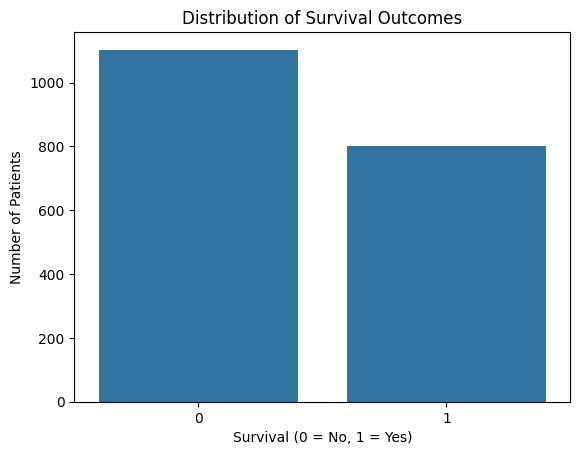

In [15]:
sns.countplot(x='overall_survival', data=df)
plt.title("Distribution of Survival Outcomes")
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

In [16]:
df['overall_survival'].value_counts()

overall_survival
0    1103
1     801
Name: count, dtype: int64

The distribution of survival outcomes shows that approximately 58% of patients did not survive, while 42% survived.

This indicates a moderately imbalanced dataset, with a higher proportion of non-surviving patients. Such imbalance is important to consider while interpreting patterns in subsequent analyses.

### Age at Diagnosis and Survival

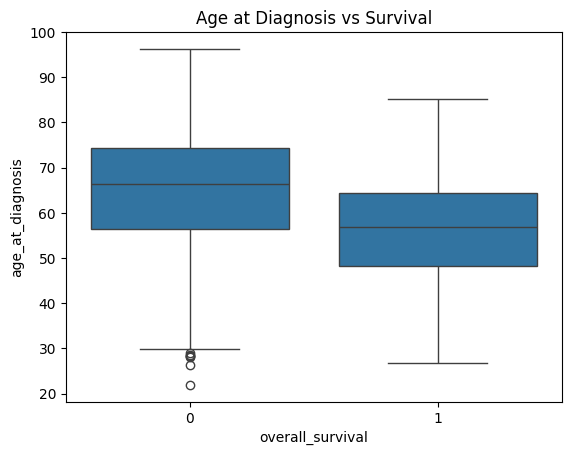

In [17]:
sns.boxplot(x='overall_survival', y='age_at_diagnosis', data=df)
plt.title("Age at Diagnosis vs Survival")
plt.show()

In [18]:
df.groupby('overall_survival')['age_at_diagnosis'].median()

overall_survival
0    66.36
1    56.74
Name: age_at_diagnosis, dtype: float64

In [19]:
survived_age = df[df['overall_survival']==1]['age_at_diagnosis']
non_survived_age = df[df['overall_survival']==0]['age_at_diagnosis']

t_stat, p_value = ttest_ind(survived_age,
                            non_survived_age)

print("P-value:", p_value)

P-value: 6.614827839918023e-42


Patients who did not survive tend to have a higher median age (~66 years) compared to those who survived (~56 years), suggesting that increasing age is associated with poorer survival outcomes.

An independent t-test was performed to statistically validate this observation, and the difference in age distribution between the two survival groups was found to be highly significant (p < 0.001). This indicates that age at diagnosis is strongly associated with patient survival in the METABRIC dataset.

Although the majority of older patients exhibited poorer outcomes, the presence of younger outliers in the non-survivor group suggests that aggressive disease progression can also occur in younger individuals.

### Tumor Size vs Survival

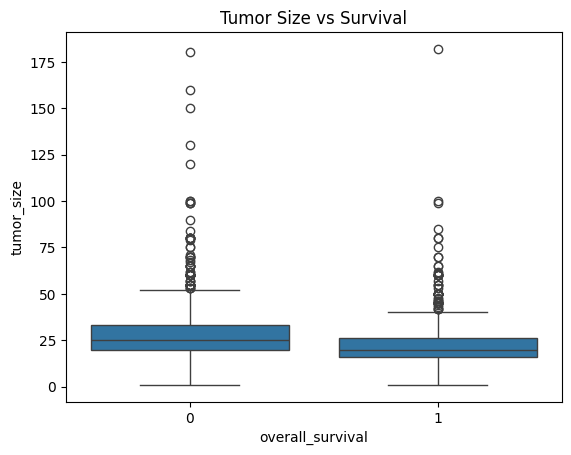

In [20]:
sns.boxplot(x='overall_survival', y='tumor_size', data=df)
plt.title("Tumor Size vs Survival")
plt.show()

In [21]:
survived_tumor = df[df['overall_survival'] == 1]['tumor_size']

non_survived_tumor = df[df['overall_survival'] == 0]['tumor_size']

t_stat, p_value = ttest_ind(survived_tumor,
                            non_survived_tumor)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -7.212964543126526
P-value: 7.86903681633796e-13


The distribution of tumor size appears relatively similar across both survival groups, although non-surviving patients exhibit several extreme high-value outliers.

An independent t-test demonstrated that the difference in tumor size between survival groups was statistically significant (p < 0.001). Patients who did not survive generally showed larger tumor sizes compared to survivors, suggesting that increased tumor burden may be associated with poorer prognosis.

However, the overlap between the two distributions indicates that tumor size alone may not fully determine survival outcome, highlighting the multifactorial nature of breast cancer progression and prognosis.


### Association between Lymph Node Involvement and Survival

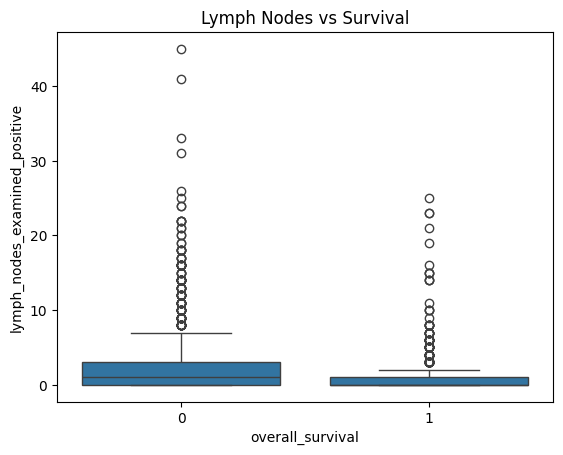

In [22]:
sns.boxplot(x='overall_survival', y='lymph_nodes_examined_positive', data=df)
plt.title("Lymph Nodes vs Survival")
plt.show()

In [23]:
survived_nodes = df[df['overall_survival'] == 1]['lymph_nodes_examined_positive']

non_survived_nodes = df[df['overall_survival'] == 0]['lymph_nodes_examined_positive']

t_stat, p_value = ttest_ind(survived_nodes,
                            non_survived_nodes)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -7.273170523324195
P-value: 5.107785879192518e-13


Patients who did not survive exhibit a higher median number of positive lymph nodes along with a wider distribution compared to surviving patients, indicating greater lymph node involvement in the non-survivor group.

An independent t-test revealed that the difference in lymph node involvement between survival groups was statistically significant (p < 0.001). This suggests that increased lymph node positivity is strongly associated with poorer survival outcomes in breast cancer patients.

Clinically, lymph node involvement reflects the spread of cancer beyond the primary tumor and is considered an important indicator of disease progression and metastatic potential.

### Nottingham Prognostic Index and Survival

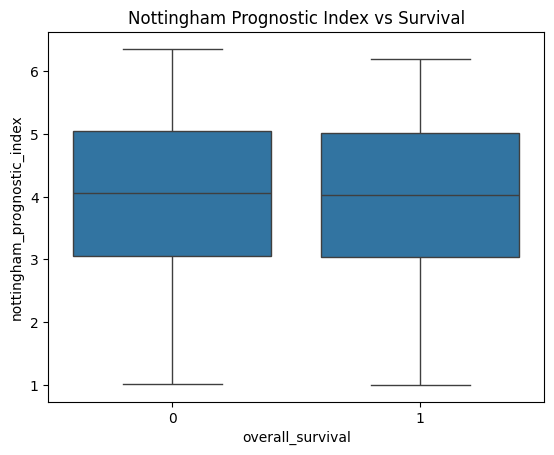

In [24]:
sns.boxplot(x='overall_survival', y='nottingham_prognostic_index', data=df)
plt.title("Nottingham Prognostic Index vs Survival")
plt.show()

In [25]:
survived_npi = df[df['overall_survival'] == 1]['nottingham_prognostic_index']

non_survived_npi = df[df['overall_survival'] == 0]['nottingham_prognostic_index']

t_stat, p_value = ttest_ind(survived_npi,
                            non_survived_npi)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -6.076572149720457
P-value: 1.479411680273567e-09


The Nottingham Prognostic Index (NPI) distributions for the two survival groups show considerable overlap, although non-surviving patients generally exhibit higher NPI values compared to survivors.

An independent t-test demonstrated that the difference in NPI between survival groups was statistically significant (p < 0.001). This suggests that higher prognostic index scores are associated with poorer survival outcomes in breast cancer patients.

Since the Nottingham Prognostic Index incorporates tumor size, lymph node involvement, and tumor grade, these findings support its clinical relevance as a composite indicator of disease severity and prognosis.

### ER Status and Survival

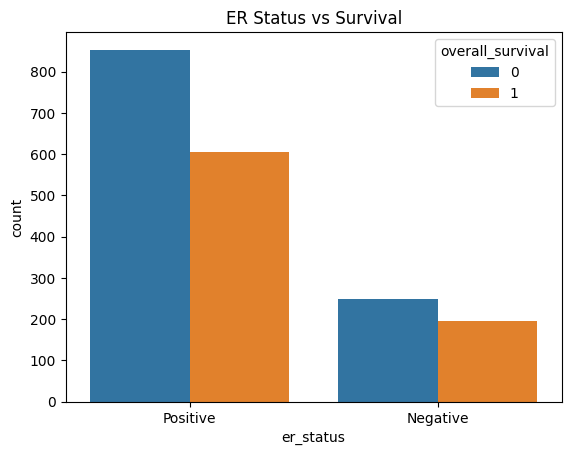

In [26]:
sns.countplot(x='er_status', hue='overall_survival', data=df)
plt.title("ER Status vs Survival")
plt.show()

In [27]:
table = pd.crosstab(df['er_status'],
                    df['overall_survival'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 0.6397499490453661
P-value: 0.42380135873577507


The distribution of survival outcomes across ER-positive and ER-negative patient groups appears relatively similar, with substantial overlap in the proportions of surviving and non-surviving patients. Although ER-positive cases are more frequent overall, this reflects the larger representation of ER-positive patients within the dataset.

A chi-square test was performed to evaluate the association between ER status and survival outcome. The results indicated that the association was not statistically significant (p > 0.05), suggesting that ER status alone may not strongly differentiate survival outcomes in this dataset.

These findings imply that while ER status is clinically important in breast cancer classification and treatment selection, its influence on survival may depend on interactions with additional clinical and molecular factors.

### Hormone Therapy and Survival

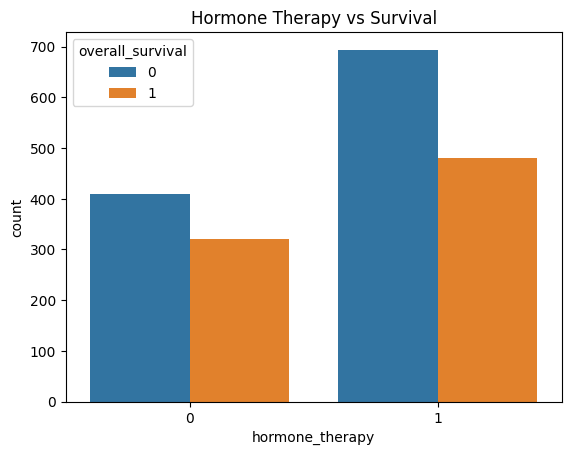

In [28]:
sns.countplot(x='hormone_therapy', hue='overall_survival', data=df)
plt.title("Hormone Therapy vs Survival")
plt.show()

In [29]:
table = pd.crosstab(df['hormone_therapy'],
                    df['overall_survival'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 1.6353715616882538
P-value: 0.20096169298567004


Patients receiving hormone therapy show higher counts of both survivors and non-survivors, primarily due to the larger number of patients undergoing hormone-based treatment within the dataset. Visual inspection alone does not clearly indicate a distinct survival advantage between the two groups.

A chi-square test was conducted to examine the association between hormone therapy and survival outcome. The analysis revealed that the association was not statistically significant (p > 0.05), suggesting that hormone therapy alone did not show a strong independent relationship with survival outcomes in this dataset.

These findings may reflect the complexity of breast cancer treatment response, where the effectiveness of hormone therapy is influenced by multiple factors such as receptor status, tumor subtype, disease stage, and combined treatment strategies.

### Tumor Stage and Survival

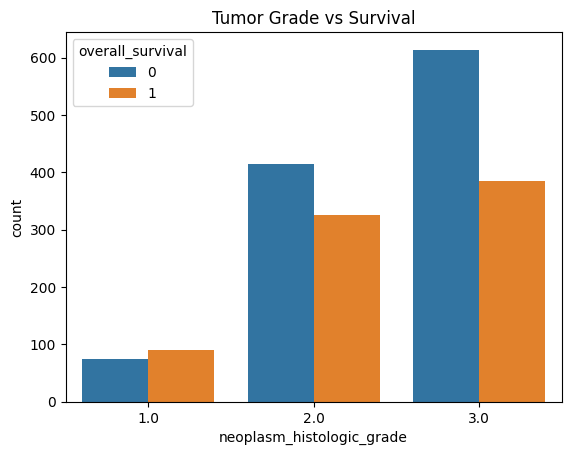

In [30]:
# Since tumor_stage column was dropped during data preprocessing, neoplasm_histologic_grade column was used instead
sns.countplot(x='neoplasm_histologic_grade', hue='overall_survival', data=df)
plt.title("Tumor Grade vs Survival")
plt.show()

In [31]:
table = pd.crosstab(df['neoplasm_histologic_grade'],
                    df['overall_survival'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 16.844512247861868
P-value: 0.00021991793060131912


Survival outcomes show a clear relationship with histologic tumor grade. Patients with lower-grade tumors (Grade 1) tend to exhibit better survival outcomes, whereas higher-grade tumors (Grade 3) are associated with a greater proportion of non-survivors.

A chi-square test demonstrated a statistically significant association between tumor grade and survival outcome (p < 0.001). This indicates that tumor grade is an important prognostic factor influencing patient survival in breast cancer.

Higher-grade tumors are generally characterized by poor differentiation, increased invasiveness, and rapid cellular proliferation, which contribute to more aggressive disease progression and poorer clinical outcomes.

## GENE EXPRESSION ANALYSIS

In addition to clinical variables, gene expression data was analyzed to explore molecular patterns associated with breast cancer.

These values represent normalized mRNA expression levels (z-scores), providing insight into the underlying biological mechanisms of the disease.

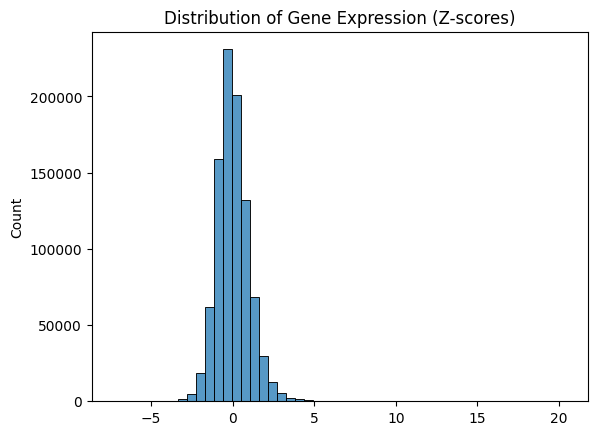

In [32]:
gene_cols = df.columns[df.columns.get_loc('brca1'):]
gene_data_raw = df[gene_cols]
gene_data = gene_data_raw.select_dtypes(include=['float64', 'int64'])
sns.histplot(gene_data.values.flatten(), bins=50)
plt.title("Distribution of Gene Expression (Z-scores)")
plt.show()

Gene expression values are centered around zero, indicating z-score normalization. The approximately normal distribution suggests that most genes exhibit moderate expression levels across patients, while only a subset show extreme over- or under-expression.

### Gene Expression Differences Between Survival Groups

To explore the molecular basis of breast cancer outcomes, gene expression data was analyzed to identify genes associated with patient survival. Since gene expression values are continuous and normalized (z-scores), only numerical gene features were retained for analysis.

Patients were divided into two groups based on survival outcome (survived vs non-survived), and gene expression levels were compared between these groups. The objective of this analysis is to identify genes that exhibit differential expression patterns potentially linked to disease prognosis.

In [33]:
gene_cols = df.columns[df.columns.get_loc('brca1'):]
gene_data = df[gene_cols].select_dtypes(include=['float64', 'int64'])
group_0 = df[df['overall_survival'] == 0]
group_1 = df[df['overall_survival'] == 1]
gene_diff = (group_0[gene_data.columns].mean() - group_1[gene_data.columns].mean()).sort_values(ascending=False)
gene_diff.head(10)

gsk3b    0.377424
kmt2c    0.348258
map4     0.334791
tsc2     0.327932
tnk2     0.315394
pdgfb    0.294616
ncoa3    0.281684
akt1     0.274601
afdn     0.267891
sdc4     0.256860
dtype: float64

To identify genes associated with survival outcomes, the mean expression of each gene was computed separately for patients who survived and those who did not. The difference between these means was then calculated to highlight genes showing the strongest differential expression between the two groups.

Positive values indicate genes upregulated in patients with poor survival outcomes.

Several identified genes, including AKT1, GSK3B, and PDGFB, are known to be involved in cancer-related pathways such as cell proliferation, signaling, and tumor progression.

### Gene Expression Patterns of Key Survival-Associated Genes

To further investigate the molecular differences associated with survival outcomes, two key genes—AKT1 and GSK3B—were selected from the top differentially expressed genes. These genes were chosen based on their strong expression differences between survival groups and their known involvement in cancer-related signaling pathways.

The expression distributions of these genes were compared between patients who survived and those who did not survive in order to visually assess separation patterns and potential prognostic relevance.

### AKT1 Plot

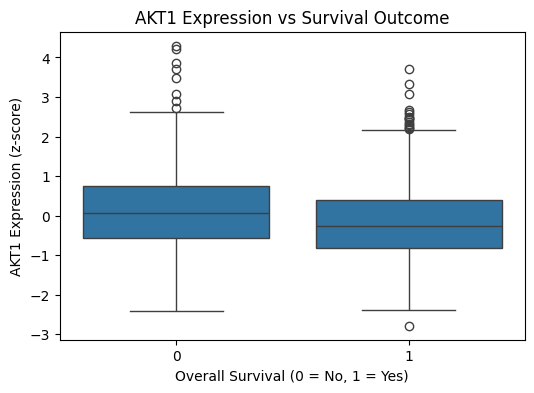

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['overall_survival'], y=df['akt1'])
plt.title("AKT1 Expression vs Survival Outcome")
plt.xlabel("Overall Survival (0 = No, 1 = Yes)")
plt.ylabel("AKT1 Expression (z-score)")
plt.show()

In [35]:
survived_akt1 = df[df['overall_survival'] == 1]['akt1']

non_survived_akt1 = df[df['overall_survival'] == 0]['akt1']

t_stat, p_value = ttest_ind(survived_akt1,
                            non_survived_akt1)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -5.967223902682073
P-value: 2.8712335570657963e-09


The expression distribution of AKT1 shows noticeable variation between survival groups, with non-surviving patients generally exhibiting higher expression levels compared to survivors.

An independent t-test demonstrated that the difference in AKT1 expression between the two survival groups was statistically significant (p < 0.001). This suggests that elevated AKT1 expression may be associated with poorer survival outcomes in breast cancer patients.

AKT1 is involved in important cancer-related signaling pathways associated with cell growth, proliferation, and survival. Increased expression of this gene may therefore contribute to aggressive tumor behavior and disease progression.

### GSK3B Plot

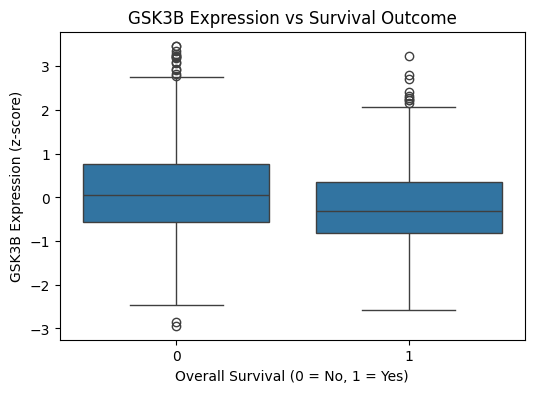

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['overall_survival'], y=df['gsk3b'])
plt.title("GSK3B Expression vs Survival Outcome")
plt.xlabel("Overall Survival (0 = No, 1 = Yes)")
plt.ylabel("GSK3B Expression (z-score)")
plt.show()

In [37]:
survived_gsk3b = df[df['overall_survival'] == 1]['gsk3b']

non_survived_gsk3b = df[df['overall_survival'] == 0]['gsk3b']

t_stat, p_value = ttest_ind(survived_gsk3b,
                            non_survived_gsk3b)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -8.270729735636083
P-value: 2.47063142228456e-16


The expression levels of GSK3B differ noticeably between survival groups, with non-surviving patients generally showing higher expression levels compared to surviving patients.

An independent t-test revealed that the difference in GSK3B expression between survival groups was statistically significant (p < 0.001). This suggests that elevated GSK3B expression may be associated with poorer prognosis and increased disease aggressiveness in breast cancer patients.

GSK3B plays an important role in multiple cellular signaling pathways involved in proliferation, apoptosis, and tumor progression. Altered expression of this gene may therefore contribute to the molecular mechanisms underlying breast cancer progression and survival outcomes.

### Average Gene Expression: Survival vs Non-Survival

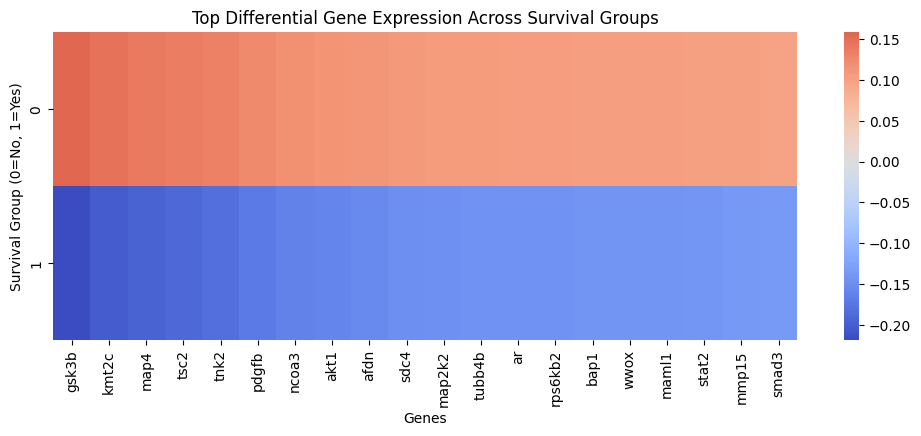

In [38]:
top_genes = gene_diff.head(20).index
mean_expr = df.groupby('overall_survival')[top_genes].mean()
plt.figure(figsize=(12,4))
sns.heatmap(mean_expr, cmap='coolwarm', center=0)
plt.title("Top Differential Gene Expression Across Survival Groups")
plt.xlabel("Genes")
plt.ylabel("Survival Group (0=No, 1=Yes)")
plt.show()

A group-wise heatmap was constructed to compare average gene expression profiles between survival groups.

### Correlation Heatmap

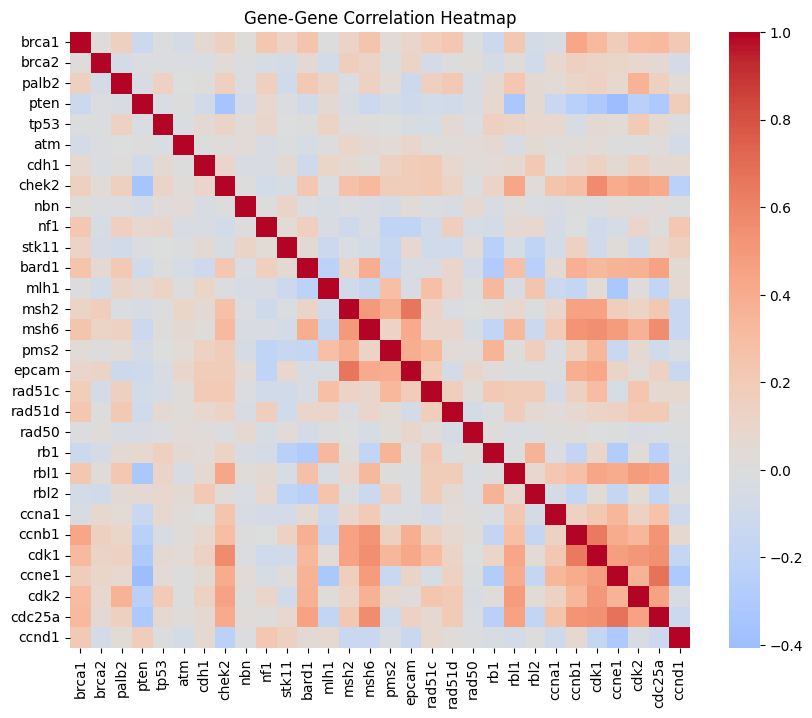

In [39]:
gene_subset = gene_data.iloc[:, :30]
corr = gene_subset.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title("Gene-Gene Correlation Heatmap")
plt.show()

A gene-gene correlation heatmap was generated to explore relationships between gene expression profiles. Several genes exhibited moderate positive and negative correlations, suggesting coordinated regulation and potential involvement in shared biological pathways.

### Integrated Gene Expression Analysis

To gain a more comprehensive understanding of gene expression patterns in breast cancer, multiple analytical perspectives were combined. First, survival-based differential expression analysis identified genes such as AKT1 and GSK3B that show distinct expression differences between survival groups, suggesting potential involvement in tumor progression and patient prognosis.

Next, a group-wise expression heatmap highlighted global shifts in gene activity between surviving and non-surviving patients, indicating that survival outcomes may be associated with coordinated changes in molecular expression patterns rather than isolated gene effects.

Finally, a gene-gene correlation analysis revealed clusters of co-expressed genes, suggesting potential functional relationships and shared regulatory mechanisms. Together, these analyses indicate that breast cancer prognosis is influenced by both individual gene activity and broader gene interaction networks.

# PREDICTIVE MODELING FOR BREAST CANCER SURVIVAL

## Research Question

The exploratory analysis identified several clinical and molecular factors associated with patient survival. However, exploratory findings alone do not indicate how effectively these variables can predict survival outcomes in unseen patients.

The objective of this section is to develop machine learning models capable of predicting breast cancer survival and to evaluate whether genomic biomarkers provide additional predictive value beyond conventional clinical indicators.

## Modelling Strategy

To investigate the predictive contribution of different feature groups, three datasets were constructed:

1. Clinical Features Only
2. Gene Expression Features Only
3. Combined Clinical + Gene Expression Features

This framework enables comparison of traditional clinical predictors against molecular biomarkers and their integrated predictive performance.

In [40]:
from scipy.stats import ttest_ind
import pandas as pd

gene_cols = df.columns[df.columns.get_loc('brca1'):]

gene_data = df[gene_cols].select_dtypes(include=['float64', 'int64'])

survived = df[df['overall_survival']==1]
non_survived = df[df['overall_survival']==0]

results = []

for gene in gene_data.columns:

    t_stat, p_value = ttest_ind(
        survived[gene],
        non_survived[gene],
        nan_policy='omit'
    )

    mean_diff = abs(
        survived[gene].mean() -
        non_survived[gene].mean()
    )

    results.append(
        [gene,p_value,mean_diff]
    )

gene_stats = pd.DataFrame(
    results,
    columns=['Gene','P_Value','Mean_Difference']
)

gene_stats = gene_stats.sort_values(
    by='P_Value'
)

gene_stats.head(20)

,Gene,P_Value,Mean_Difference
451,hsd17b11,1.484763e-21,0.437732
437,cdkn2c,3.542394e-18,0.399819
47,jak1,1.134874e-17,0.393810
169,gsk3b,2.470631e-16,0.377424
478,spry2,4.123817e-16,0.374626
358,lama2,3.447597e-14,0.349485
281,kmt2c,4.243720e-14,0.348258
140,casp8,1.416756e-13,0.341054
268,tgfbr2,2.740887e-13,0.337043
301,map4,3.956840e-13,0.334791


## Selection of Candidate Genomic Biomarkers

The METABRIC dataset contains hundreds of gene expression measurements. Including all genes in a predictive model may increase dimensionality, reduce interpretability, and introduce noise.

To identify biologically relevant candidate biomarkers, differential expression analysis was performed between survival groups using independent t-tests. Genes were then ranked according to statistical significance.

In [41]:
from scipy.stats import ttest_ind
import pandas as pd

gene_cols = df.columns[df.columns.get_loc('brca1'):]

gene_data = df[gene_cols].select_dtypes(include=['float64', 'int64'])

survived = df[df['overall_survival'] == 1]
non_survived = df[df['overall_survival'] == 0]

results = []

for gene in gene_data.columns:

    t_stat, p_value = ttest_ind(
        survived[gene],
        non_survived[gene],
        nan_policy='omit'
    )

    mean_diff = abs(
        survived[gene].mean() -
        non_survived[gene].mean()
    )

    results.append(
        [gene, p_value, mean_diff]
    )

gene_stats = pd.DataFrame(
    results,
    columns=['Gene', 'P_Value', 'Mean_Difference']
)

gene_stats = gene_stats.sort_values(
    by='P_Value'
)

gene_stats.head(20)

,Gene,P_Value,Mean_Difference
451,hsd17b11,1.484763e-21,0.437732
437,cdkn2c,3.542394e-18,0.399819
47,jak1,1.134874e-17,0.393810
169,gsk3b,2.470631e-16,0.377424
478,spry2,4.123817e-16,0.374626
358,lama2,3.447597e-14,0.349485
281,kmt2c,4.243720e-14,0.348258
140,casp8,1.416756e-13,0.341054
268,tgfbr2,2.740887e-13,0.337043
301,map4,3.956840e-13,0.334791


Several genes exhibited significant differential expression between survival groups. Many of the highest-ranked genes, including GSK3B, JAK1, MYC, STAT5A, IGF1, and TGFBR2, are involved in pathways associated with cell proliferation, signaling, apoptosis, and tumor progression.

These genes represent biologically plausible candidate biomarkers and were selected for downstream predictive modeling.

Differential expression analysis identified several genes exhibiting significant expression differences between survival groups. To reduce dimensionality while retaining biologically relevant information, the top 20 genes ranked by statistical significance were selected as candidate genomic biomarkers for predictive modeling.

In [42]:
selected_genes = gene_stats.head(20)['Gene'].tolist()

selected_genes

['hsd17b11',
 'cdkn2c',
 'jak1',
 'gsk3b',
 'spry2',
 'lama2',
 'kmt2c',
 'casp8',
 'tgfbr2',
 'map4',
 'abcb1',
 'kit',
 'tsc2',
 'pdgfra',
 'igf1',
 'tnk2',
 'myc',
 'stat5a',
 'smad4',
 'ccnd2']

## Construction of Modeling Datasets

Three feature sets were created:

- Clinical Dataset
- Genomic Dataset
- Combined Dataset

This enables comparison of predictive performance across traditional clinical variables, molecular biomarkers, and their integration.

In [44]:
clinical_features = [
    'age_at_diagnosis',
    'tumor_size',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',
    'neoplasm_histologic_grade',
    'er_status',
    'her2_status',
    'hormone_therapy'
]

X_clinical = df[clinical_features]

X_genomic = df[selected_genes]

X_combined = df[
    clinical_features +
    selected_genes
]

y = df['overall_survival']

In [45]:
print("Clinical:", X_clinical.shape)
print("Genomic:", X_genomic.shape)
print("Combined:", X_combined.shape)
print("Target:", y.shape)

Clinical: (1904, 8)
Genomic: (1904, 20)
Combined: (1904, 28)
Target: (1904,)


The clinical dataset consisted of established prognostic indicators routinely used in breast cancer management. The genomic dataset contained the twenty most significant survival-associated genes identified through differential expression analysis. A combined dataset integrating both feature groups was also constructed to evaluate the incremental predictive value of molecular biomarkers.

## Train-Test Split

To evaluate model generalizability, each dataset was divided into training and testing subsets. A stratified split was used to preserve the class distribution of survival outcomes across both sets.

The same target variable (`overall_survival`) was used for all experiments.

In [46]:
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clinical,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_genomic,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Xcomb_train, Xcomb_test, ycomb_train, ycomb_test = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print("Clinical Train:", Xc_train.shape)
print("Clinical Test:", Xc_test.shape)

print("\nGenomic Train:", Xg_train.shape)
print("Genomic Test:", Xg_test.shape)

print("\nCombined Train:", Xcomb_train.shape)
print("Combined Test:", Xcomb_test.shape)

Clinical Train: (1523, 8)
Clinical Test: (381, 8)

Genomic Train: (1523, 20)
Genomic Test: (381, 20)

Combined Train: (1523, 28)
Combined Test: (381, 28)


## Data Preprocessing

Machine learning algorithms require numerical representations of categorical variables and may be sensitive to differences in feature scale.

Categorical clinical variables were encoded using one-hot encoding, while numerical variables were standardized. Preprocessing was performed within a unified pipeline to ensure consistency and prevent data leakage.

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [49]:
clinical_numeric = [
    'age_at_diagnosis',
    'tumor_size',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',
    'neoplasm_histologic_grade'
]

clinical_categorical = [
    'er_status',
    'her2_status'
]

preprocessor_clinical = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), clinical_numeric),
        ('cat', OneHotEncoder(drop='first'), clinical_categorical)
    ]
)

## Logistic Regression Baseline Model

Logistic Regression was selected as the initial baseline model due to its simplicity and interpretability. Establishing a baseline allows comparison against more complex machine learning algorithms and helps determine whether additional model complexity provides meaningful predictive improvements.

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

### Clinical Logistic Regression

In [51]:
clinical_logreg = Pipeline([
    ('preprocessor', preprocessor_clinical),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

clinical_logreg.fit(Xc_train, yc_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [52]:
clinical_pred = clinical_logreg.predict(Xc_test)

clinical_prob = clinical_logreg.predict_proba(
    Xc_test
)[:,1]

print("Accuracy:",
      accuracy_score(yc_test, clinical_pred))

print("Precision:",
      precision_score(yc_test, clinical_pred))

print("Recall:",
      recall_score(yc_test, clinical_pred))

print("F1:",
      f1_score(yc_test, clinical_pred))

print("ROC-AUC:",
      roc_auc_score(yc_test, clinical_prob))

Accuracy: 0.6614173228346457
Precision: 0.6183206106870229
Recall: 0.50625
F1: 0.5567010309278351
ROC-AUC: 0.6925622171945701


The clinical-only Logistic Regression model achieved moderate predictive performance (ROC-AUC ≈ 0.69), indicating that traditional clinical variables contain meaningful prognostic information. However, the results also suggest that additional sources of information may be required to improve survival prediction accuracy.

This motivates further investigation of genomic biomarkers and integrated clinical-genomic models.

### Genomic Feature Model

To evaluate the predictive value of molecular biomarkers independently of clinical information, a Logistic Regression model was trained using only the selected gene expression features.

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

genomic_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

genomic_logreg.fit(
    Xg_train,
    yg_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [54]:
genomic_pred = genomic_logreg.predict(
    Xg_test
)

genomic_prob = genomic_logreg.predict_proba(
    Xg_test
)[:,1]

print("Accuracy:",
      accuracy_score(yg_test, genomic_pred))

print("Precision:",
      precision_score(yg_test, genomic_pred))

print("Recall:",
      recall_score(yg_test, genomic_pred))

print("F1:",
      f1_score(yg_test, genomic_pred))

print("ROC-AUC:",
      roc_auc_score(yg_test, genomic_prob))

Accuracy: 0.6456692913385826
Precision: 0.6016260162601627
Recall: 0.4625
F1: 0.5229681978798587
ROC-AUC: 0.6665441176470589


The genomic-only Logistic Regression model achieved predictive performance comparable to the clinical-only model, suggesting that the selected gene expression biomarkers capture meaningful prognostic information.

Although performance was slightly lower than the clinical model, the relatively small difference in ROC-AUC indicates that molecular features alone contain substantial information regarding patient survival outcomes.

### Integrated Clinical-Genomic Model

To evaluate whether molecular biomarkers provide additional prognostic value beyond conventional clinical indicators, a Logistic Regression model was trained using both clinical and genomic features.

In [55]:
combined_numeric = [
    'age_at_diagnosis',
    'tumor_size',
    'lymph_nodes_examined_positive',
    'nottingham_prognostic_index',
    'neoplasm_histologic_grade'
] + selected_genes

combined_categorical = [
    'er_status',
    'her2_status'
]

combined_preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         StandardScaler(),
         combined_numeric),

        ('cat',
         OneHotEncoder(drop='first'),
         combined_categorical)
    ]
)

In [56]:
combined_logreg = Pipeline([
    ('preprocessor',
     combined_preprocessor),

    ('model',
     LogisticRegression(
         max_iter=2000,
         random_state=42
     ))
])

combined_logreg.fit(
    Xcomb_train,
    ycomb_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [57]:
combined_pred = combined_logreg.predict(
    Xcomb_test
)

combined_prob = combined_logreg.predict_proba(
    Xcomb_test
)[:,1]

print("Accuracy:",
      accuracy_score(ycomb_test,
                     combined_pred))

print("Precision:",
      precision_score(ycomb_test,
                      combined_pred))

print("Recall:",
      recall_score(ycomb_test,
                   combined_pred))

print("F1:",
      f1_score(ycomb_test,
               combined_pred))

print("ROC-AUC:",
      roc_auc_score(ycomb_test,
                    combined_prob))

Accuracy: 0.6745406824146981
Precision: 0.6285714285714286
Recall: 0.55
F1: 0.5866666666666667
ROC-AUC: 0.7339932126696833


The integrated clinical-genomic model achieved the highest predictive performance among the Logistic Regression models evaluated.

Compared with the clinical-only model, incorporation of gene expression biomarkers increased ROC-AUC from approximately 0.69 to 0.73, indicating that molecular features provide complementary prognostic information beyond conventional clinical variables.

These findings support the hypothesis that integrating genomic and clinical information improves survival prediction in breast cancer patients.

In [58]:
results_lr = pd.DataFrame({
    'Dataset': [
        'Clinical',
        'Genomic',
        'Combined'
    ],
    'Accuracy': [
        0.6614173228346457,
        0.6456692913385826,
        0.6745406824146981
    ],
    'F1': [
        0.5567010309278351,
        0.5229681978798587,
        0.5866666666666667
    ],
    'ROC_AUC': [
        0.6925622171945701,
        0.6665441176470589,
        0.7339932126696833
    ]
})

results_lr

,Dataset,Accuracy,F1,ROC_AUC
0,Clinical,0.661417,0.556701,0.692562
1,Genomic,0.645669,0.522968,0.666544
2,Combined,0.674541,0.586667,0.733993


## Random Forest Model

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and aggregates their predictions. Unlike Logistic Regression, Random Forest can capture nonlinear relationships and complex interactions between clinical and molecular features.

This makes it particularly suitable for biological datasets where feature interactions may influence disease outcomes.

In [59]:
from sklearn.ensemble import RandomForestClassifier

### Clinical Random Forest Model

In [60]:
rf_clinical = Pipeline([
    ('preprocessor', preprocessor_clinical),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ))
])

rf_clinical.fit(Xc_train, yc_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [61]:
rf_clinical_pred = rf_clinical.predict(Xc_test)

rf_clinical_prob = rf_clinical.predict_proba(
    Xc_test
)[:,1]

print("Accuracy:",
      accuracy_score(yc_test,
                     rf_clinical_pred))

print("Precision:",
      precision_score(yc_test,
                      rf_clinical_pred))

print("Recall:",
      recall_score(yc_test,
                   rf_clinical_pred))

print("F1:",
      f1_score(yc_test,
               rf_clinical_pred))

print("ROC-AUC:",
      roc_auc_score(yc_test,
                    rf_clinical_prob))

Accuracy: 0.6272965879265092
Precision: 0.5548780487804879
Recall: 0.56875
F1: 0.5617283950617284
ROC-AUC: 0.6787330316742082


The clinical Random Forest model achieved a ROC-AUC of approximately 0.68, which was comparable to but slightly lower than the corresponding Logistic Regression model.

This suggests that the predictive information contained within the clinical variables may be captured effectively using relatively simple relationships, with limited evidence of strong nonlinear interactions.

### Genomic Random Forest Model

In [62]:
rf_genomic = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_genomic.fit(
    Xg_train,
    yg_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
rf_genomic_pred = rf_genomic.predict(Xg_test)

rf_genomic_prob = rf_genomic.predict_proba(
    Xg_test
)[:,1]

print("Accuracy:",
      accuracy_score(yg_test,
                     rf_genomic_pred))

print("Precision:",
      precision_score(yg_test,
                      rf_genomic_pred))

print("Recall:",
      recall_score(yg_test,
                   rf_genomic_pred))

print("F1:",
      f1_score(yg_test,
               rf_genomic_pred))

print("ROC-AUC:",
      roc_auc_score(yg_test,
                    rf_genomic_prob))

Accuracy: 0.6272965879265092
Precision: 0.5789473684210527
Recall: 0.4125
F1: 0.48175182481751827
ROC-AUC: 0.6628817873303168


The genomic Random Forest model achieved predictive performance similar to the genomic Logistic Regression model.

The comparable results obtained across algorithms suggest that the selected gene expression biomarkers contain reproducible prognostic information, although their predictive power alone remains lower than that of the integrated clinical-genomic dataset.

### Integrated Clinical-Genomic Random Forest Model

In [64]:
rf_combined = Pipeline([
    ('preprocessor',
     combined_preprocessor),

    ('model',
     RandomForestClassifier(
         n_estimators=300,
         random_state=42
     ))
])

rf_combined.fit(
    Xcomb_train,
    ycomb_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [65]:
rf_combined_pred = rf_combined.predict(
    Xcomb_test
)

rf_combined_prob = rf_combined.predict_proba(
    Xcomb_test
)[:,1]

print("Accuracy:",
      accuracy_score(ycomb_test,
                     rf_combined_pred))

print("Precision:",
      precision_score(ycomb_test,
                      rf_combined_pred))

print("Recall:",
      recall_score(ycomb_test,
                   rf_combined_pred))

print("F1:",
      f1_score(ycomb_test,
               rf_combined_pred))

print("ROC-AUC:",
      roc_auc_score(ycomb_test,
                    rf_combined_prob))

Accuracy: 0.6929133858267716
Precision: 0.672
Recall: 0.525
F1: 0.5894736842105263
ROC-AUC: 0.7328902714932127


The integrated clinical-genomic Random Forest model achieved the highest performance among the Random Forest models evaluated.

Consistent with previous Logistic Regression results, combining clinical and molecular information improved prediction relative to either feature group individually. This finding further supports the hypothesis that genomic biomarkers provide complementary prognostic information beyond conventional clinical risk factors.

### Comparison of Logistic Regression and Random Forest

Across both Logistic Regression and Random Forest models, the integrated clinical-genomic dataset consistently produced the strongest predictive performance.

Interestingly, Random Forest did not substantially outperform Logistic Regression, suggesting that much of the predictive signal may be explained through relatively simple relationships among the selected clinical and genomic variables.

The consistency of findings across multiple algorithms strengthens confidence in the observed contribution of genomic biomarkers to survival prediction.

## Gradient Boosting Model

Gradient Boosting is an ensemble learning technique that builds decision trees sequentially, with each new tree correcting errors made by previous trees.

Compared with Random Forest, Gradient Boosting often achieves stronger predictive performance on structured tabular datasets by focusing learning on difficult-to-classify observations.

The algorithm was evaluated using clinical, genomic, and integrated feature sets to determine whether more sophisticated nonlinear modeling improves survival prediction.

In [66]:
from sklearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

### Clinical Gradient Boosting Model

In [67]:
gb_clinical = Pipeline([
    ('preprocessor', preprocessor_clinical),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_clinical.fit(
    Xc_train,
    yc_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [68]:
gb_clinical_pred = gb_clinical.predict(
    Xc_test
)

gb_clinical_prob = gb_clinical.predict_proba(
    Xc_test
)[:, 1]

print("Accuracy:",
      accuracy_score(yc_test,
                     gb_clinical_pred))

print("Precision:",
      precision_score(yc_test,
                      gb_clinical_pred))

print("Recall:",
      recall_score(yc_test,
                   gb_clinical_pred))

print("F1:",
      f1_score(yc_test,
               gb_clinical_pred))

print("ROC-AUC:",
      roc_auc_score(yc_test,
                    gb_clinical_prob))

Accuracy: 0.6482939632545932
Precision: 0.5942028985507246
Recall: 0.5125
F1: 0.5503355704697986
ROC-AUC: 0.6979779411764706


### Genomic Gradient Boosting Model

In [69]:
gb_genomic = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_genomic.fit(
    Xg_train,
    yg_train
)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [70]:
gb_genomic_pred = gb_genomic.predict(
    Xg_test
)

gb_genomic_prob = gb_genomic.predict_proba(
    Xg_test
)[:,1]

print("Accuracy:",
      accuracy_score(yg_test,
                     gb_genomic_pred))

print("Precision:",
      precision_score(yg_test,
                      gb_genomic_pred))

print("Recall:",
      recall_score(yg_test,
                   gb_genomic_pred))

print("F1:",
      f1_score(yg_test,
               gb_genomic_pred))

print("ROC-AUC:",
      roc_auc_score(yg_test,
                    gb_genomic_prob))

Accuracy: 0.6325459317585301
Precision: 0.5793650793650794
Recall: 0.45625
F1: 0.5104895104895105
ROC-AUC: 0.6489819004524886


### Integrated Clinical-Genomic Gradient Boosting Model

In [71]:
gb_combined = Pipeline([
    ('preprocessor',
     combined_preprocessor),

    ('model',
     GradientBoostingClassifier(
         n_estimators=100,
         learning_rate=0.1,
         random_state=42
     ))
])

gb_combined.fit(
    Xcomb_train,
    ycomb_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [72]:
gb_combined_pred = gb_combined.predict(
    Xcomb_test
)

gb_combined_prob = gb_combined.predict_proba(
    Xcomb_test
)[:,1]

print("Accuracy:",
      accuracy_score(ycomb_test,
                     gb_combined_pred))

print("Precision:",
      precision_score(ycomb_test,
                      gb_combined_pred))

print("Recall:",
      recall_score(ycomb_test,
                   gb_combined_pred))

print("F1:",
      f1_score(ycomb_test,
               gb_combined_pred))

print("ROC-AUC:",
      roc_auc_score(ycomb_test,
                    gb_combined_prob))

Accuracy: 0.6771653543307087
Precision: 0.6275862068965518
Recall: 0.56875
F1: 0.5967213114754099
ROC-AUC: 0.7236990950226244


## Comparison of Machine Learning Models

To evaluate the relative contribution of clinical and genomic features, three machine learning algorithms were compared across the clinical-only, genomic-only, and integrated clinical-genomic datasets.

Performance was assessed using Accuracy, F1-score, and ROC-AUC.

In [73]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest",
        "Random Forest",
        "Gradient Boosting",
        "Gradient Boosting",
        "Gradient Boosting"
    ],

    "Dataset": [
        "Clinical",
        "Genomic",
        "Combined",
        "Clinical",
        "Genomic",
        "Combined",
        "Clinical",
        "Genomic",
        "Combined"
    ],

    "ROC_AUC": [
        0.693,
        0.667,
        0.734,
        0.679,
        0.663,
        0.733,
        0.698,
        0.649,
        0.724
    ]
})

results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Dataset,ROC_AUC
2,Logistic Regression,Combined,0.734
5,Random Forest,Combined,0.733
8,Gradient Boosting,Combined,0.724
6,Gradient Boosting,Clinical,0.698
0,Logistic Regression,Clinical,0.693
3,Random Forest,Clinical,0.679
1,Logistic Regression,Genomic,0.667
4,Random Forest,Genomic,0.663
7,Gradient Boosting,Genomic,0.649


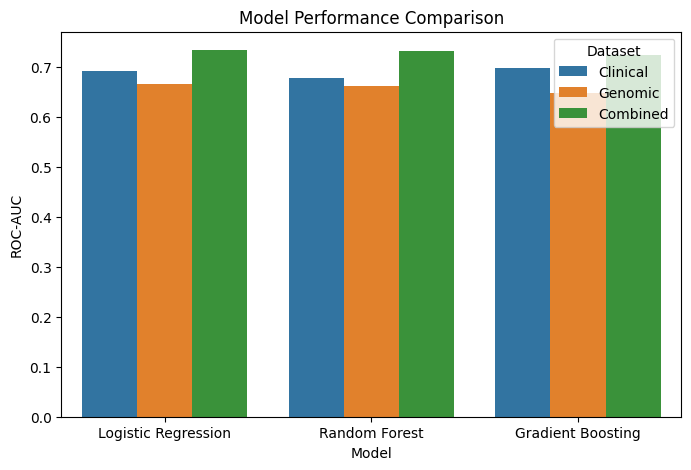

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="ROC_AUC",
    hue="Dataset"
)

plt.title("Model Performance Comparison")
plt.ylabel("ROC-AUC")
plt.show()

## Feature Importance Analysis

While predictive performance indicates how accurately a model can classify survival outcomes, it does not reveal which variables contribute most strongly to the predictions.

To improve interpretability, feature importance scores were extracted from the combined Random Forest model. These scores quantify the relative contribution of each clinical and genomic feature to the model's decision-making process.

Identifying important features may provide biological insights into factors associated with breast cancer prognosis.

In [75]:
feature_names = rf_combined.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = rf_combined.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
0,num__age_at_diagnosis,0.117251
3,num__nottingham_prognostic_index,0.050584
7,num__jak1,0.045467
12,num__casp8,0.042494
8,num__gsk3b,0.042263
22,num__stat5a,0.041458
23,num__smad4,0.041244
5,num__hsd17b11,0.040478
20,num__tnk2,0.038941
16,num__kit,0.038919


### Top Predictive Features

The top-ranked features identified by the Random Forest model were visualized to better understand which clinical and genomic variables contributed most strongly to survival prediction.

Higher importance scores indicate greater influence on model decision-making.

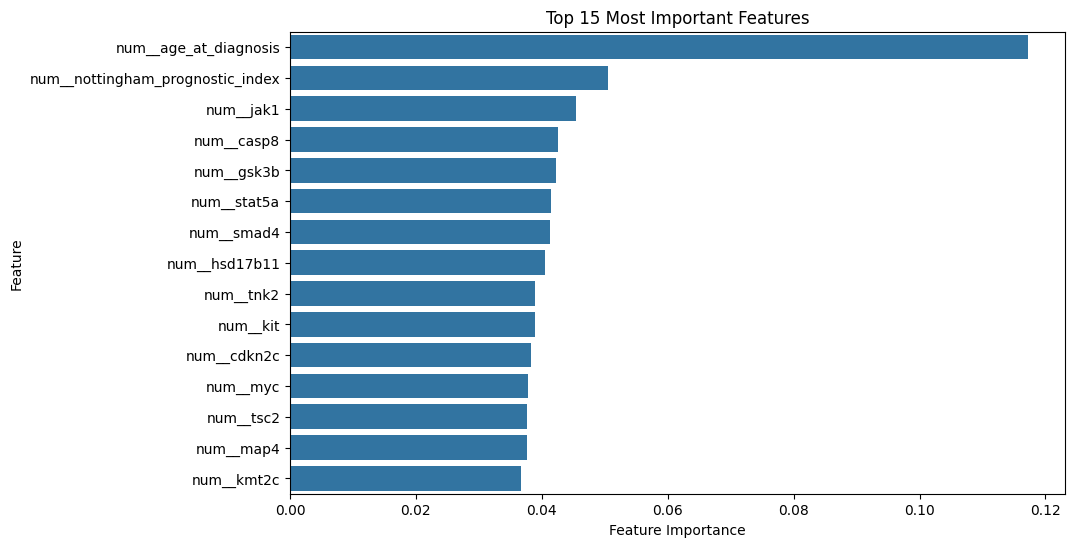

In [76]:
top15 = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

The feature importance analysis revealed that both clinical and genomic variables contributed substantially to survival prediction.

Several established clinical prognostic indicators ranked among the most influential predictors, while multiple gene expression biomarkers also demonstrated meaningful predictive value.

These findings support the hypothesis that molecular information complements traditional clinical factors and contributes additional prognostic information beyond conventional risk indicators alone.

## Biological Interpretation of Key Predictors

The Random Forest feature importance analysis identified both clinical and molecular variables as major contributors to survival prediction.

Among clinical variables, age at diagnosis and Nottingham Prognostic Index (NPI) emerged as the strongest predictors. Both are well-established prognostic indicators in breast cancer and are routinely used in clinical decision-making.

Several gene expression biomarkers also ranked highly, including JAK1, CASP8, GSK3B, STAT5A, SMAD4, MYC, and TSC2.

Many of these genes participate in pathways involved in cell proliferation, apoptosis, immune signaling, and tumor progression. For example:

- JAK1 and STAT5A are components of the JAK-STAT signaling pathway, which regulates cell growth and immune responses.
- CASP8 plays a critical role in apoptosis and programmed cell death.
- GSK3B is involved in multiple signaling pathways associated with tumor progression.
- MYC is a well-known oncogene that promotes cellular proliferation.
- SMAD4 participates in TGF-β signaling, which influences tumor development and metastasis.

The presence of both clinical and molecular predictors among the most important features supports the hypothesis that genomic biomarkers provide complementary prognostic information beyond traditional clinical factors.

## Risk Stratification Analysis

While binary survival prediction provides useful information, clinical decision-making often benefits from stratifying patients into risk categories.

To explore the practical utility of the predictive model, the best-performing model (Combined Logistic Regression) was used to estimate survival probabilities for patients in the test set.

Predicted survival probabilities were subsequently converted into risk scores and patients were categorized into low-, medium-, and high-risk groups.

In [77]:
survival_prob = combined_logreg.predict_proba(
    Xcomb_test
)[:,1]

risk_score = 1 - survival_prob

risk_df = pd.DataFrame({
    'Actual_Survival': ycomb_test,
    'Survival_Probability': survival_prob,
    'Risk_Score': risk_score
})

risk_df.head()

,Actual_Survival,Survival_Probability,Risk_Score
938,0,0.514244,0.485756
792,0,0.189890,0.810110
317,1,0.566907,0.433093
890,1,0.275614,0.724386
1470,1,0.494566,0.505434


### Patient Risk Stratification

Risk scores were divided into three categories:

- Low Risk
- Medium Risk
- High Risk

This stratification provides a clinically interpretable framework for identifying patients with different levels of predicted mortality risk.

In [78]:
risk_df['Risk_Group'] = pd.cut(
    risk_df['Risk_Score'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_df.head()

,Actual_Survival,Survival_Probability,Risk_Score,Risk_Group
938,0,0.514244,0.485756,Medium Risk
792,0,0.189890,0.810110,High Risk
317,1,0.566907,0.433093,Medium Risk
890,1,0.275614,0.724386,High Risk
1470,1,0.494566,0.505434,Medium Risk


In [79]:
risk_df['Risk_Group'].value_counts()

Risk_Group
High Risk      157
Medium Risk    150
Low Risk        74
Name: count, dtype: int64

### Distribution of Patients Across Risk Groups

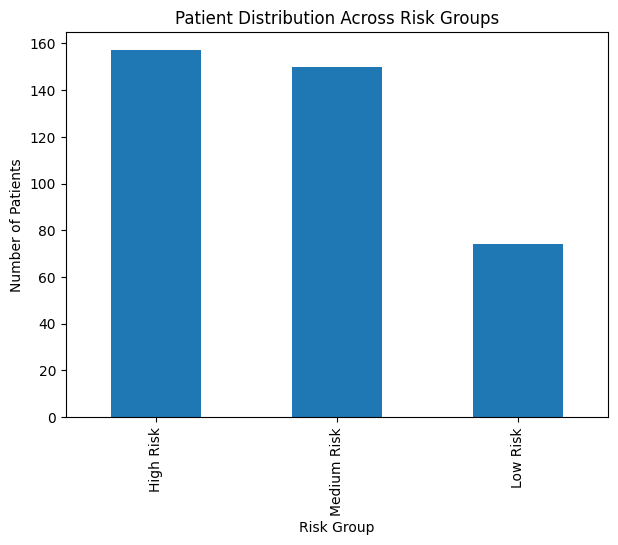

In [80]:
plt.figure(figsize=(7,5))

risk_df['Risk_Group'].value_counts().plot(
    kind='bar'
)

plt.title("Patient Distribution Across Risk Groups")
plt.xlabel("Risk Group")
plt.ylabel("Number of Patients")

plt.show()

### Survival Outcomes Within Risk Groups

To evaluate whether the predicted risk categories correspond to meaningful clinical outcomes, the observed survival rate was calculated for each risk group.

In [81]:
risk_summary = risk_df.groupby(
    'Risk_Group'
)['Actual_Survival'].mean()

risk_summary

Risk_Group
Low Risk       0.702703
Medium Risk    0.493333
High Risk      0.216561
Name: Actual_Survival, dtype: float64

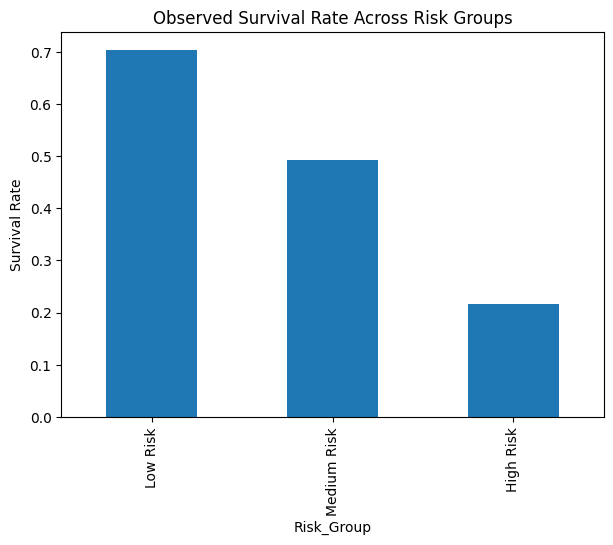

In [82]:
plt.figure(figsize=(7,5))

risk_summary.plot(
    kind='bar'
)

plt.title("Observed Survival Rate Across Risk Groups")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation of Risk Stratification Results

The risk stratification analysis demonstrated clear separation of patients into clinically meaningful groups.

Patients classified as low risk exhibited an observed survival rate of approximately 70%, whereas high-risk patients showed a survival rate of only 22%. Medium-risk patients displayed intermediate outcomes.

The progressive decline in observed survival across risk categories indicates that the model successfully captures prognostic information associated with patient outcomes.

These findings suggest that the integrated clinical-genomic model may have potential utility for identifying patient subgroups with differing levels of clinical risk.

## SHAP Explainability Analysis

While feature importance identifies variables that contribute strongly to model performance, it does not indicate how individual features influence predictions.

To improve model interpretability, SHAP (SHapley Additive exPlanations) was applied to the best-performing model. SHAP provides a unified framework for quantifying the contribution of each feature to model predictions.

This analysis helps identify which clinical and genomic factors increase or decrease predicted survival probability.

In [83]:
import shap

X_train_transformed = (
    combined_logreg.named_steps['preprocessor']
    .transform(Xcomb_train)
)

X_test_transformed = (
    combined_logreg.named_steps['preprocessor']
    .transform(Xcomb_test)
)

feature_names = (
    combined_logreg.named_steps['preprocessor']
    .get_feature_names_out()
)

C:\Users\jasvi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [84]:
explainer = shap.LinearExplainer(
    combined_logreg.named_steps['model'],
    X_train_transformed
)

shap_values = explainer.shap_values(
    X_test_transformed
)

Background dataset has 1523 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1523 when initializing the masker.


### Global SHAP Feature Importance

A SHAP summary plot was generated to visualize the overall impact of features on model predictions across all patients.

Features appearing near the top of the plot contribute most strongly to prediction outcomes. Positive SHAP values indicate factors that increase predicted survival probability, whereas negative values decrease predicted survival probability.

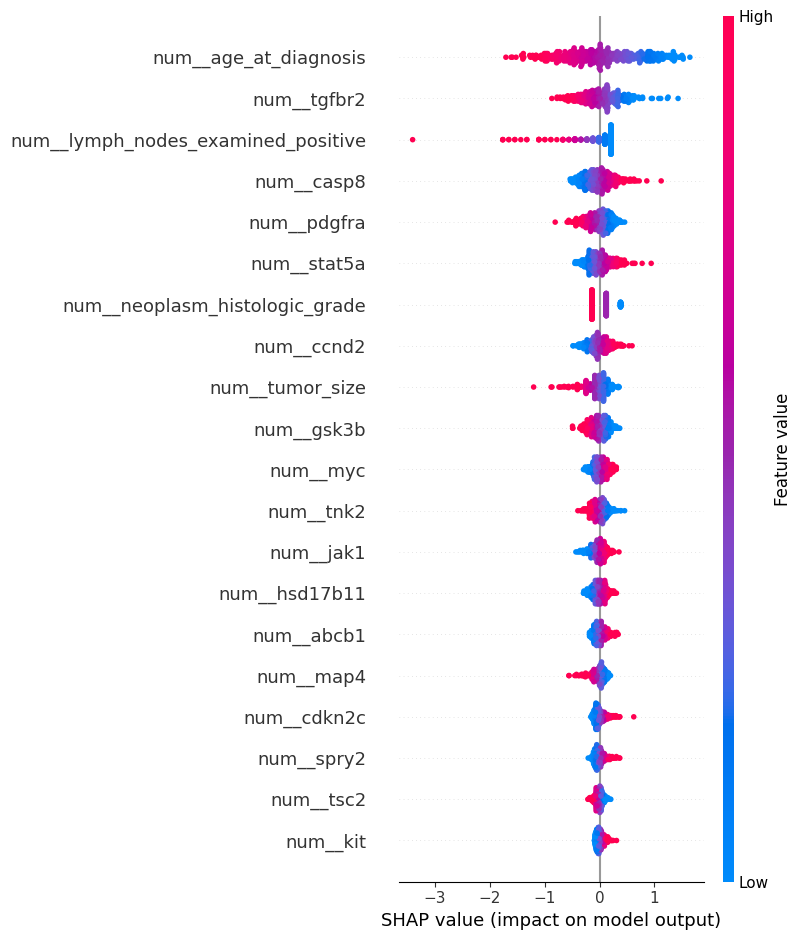

In [85]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

### Interpretation of SHAP Summary Plot

The SHAP summary plot provides a global explanation of model behavior across all patients.

Age at diagnosis emerged as the strongest predictor of survival outcome, indicating that patient age has a substantial influence on model predictions. Several established clinical prognostic factors, including lymph node involvement, histologic grade, and tumor size, also ranked among the most influential variables.

Importantly, multiple genomic features such as TGFBR2, CASP8, PDGFRA, STAT5A, GSK3B, MYC, and JAK1 demonstrated significant contributions to model predictions. Many of these genes are involved in cellular proliferation, apoptosis, growth signaling, and tumor progression pathways.

The presence of both clinical and genomic predictors among the top SHAP features suggests that integrating molecular information with traditional clinical variables improves survival prediction and provides biologically meaningful insights into breast cancer prognosis.

# Clinical Decision Support Scenario

To demonstrate the practical application of the predictive model, individual patient predictions were examined.

Rather than focusing solely on overall model performance, this analysis illustrates how the integrated clinical-genomic model could potentially support personalized risk assessment.

Patients with the highest and lowest predicted survival probabilities were identified and compared.

In [86]:
patient_predictions = pd.DataFrame({
    'Actual_Survival': ycomb_test,
    'Predicted_Survival_Probability':
        combined_logreg.predict_proba(Xcomb_test)[:,1]
})

patient_predictions.head()

,Actual_Survival,Predicted_Survival_Probability
938,0,0.514244
792,0,0.189890
317,1,0.566907
890,1,0.275614
1470,1,0.494566


In [87]:
highest_survival_idx = (
    patient_predictions[
        'Predicted_Survival_Probability'
    ].idxmax()
)

lowest_survival_idx = (
    patient_predictions[
        'Predicted_Survival_Probability'
    ].idxmin()
)

print("Highest Survival Patient:", highest_survival_idx)
print("Lowest Survival Patient:", lowest_survival_idx)

Highest Survival Patient: 508
Lowest Survival Patient: 1888


In [88]:
low_risk_patient = Xcomb_test.loc[508]
high_risk_patient = Xcomb_test.loc[1888]

print("LOW RISK PATIENT")
display(low_risk_patient)

print("\nHIGH RISK PATIENT")
display(high_risk_patient)

LOW RISK PATIENT


age_at_diagnosis                    60.59
tumor_size                            8.0
lymph_nodes_examined_positive         0.0
nottingham_prognostic_index         4.016
neoplasm_histologic_grade             3.0
er_status                        Negative
her2_status                      Negative
hormone_therapy                         0
hsd17b11                           2.3038
cdkn2c                             2.0982
jak1                                2.354
gsk3b                             -1.4713
spry2                             -0.0743
lama2                             -0.6558
kmt2c                              0.1244
casp8                              4.5385
tgfbr2                             2.1126
map4                              -0.4203
abcb1                              2.2058
kit                               -0.4266
tsc2                              -0.6535
pdgfra                            -1.0599
igf1                              -0.7067
tnk2                              


HIGH RISK PATIENT


age_at_diagnosis                    54.42
tumor_size                           30.0
lymph_nodes_examined_positive        33.0
nottingham_prognostic_index          5.06
neoplasm_histologic_grade             2.0
er_status                        Positive
her2_status                      Negative
hormone_therapy                         1
hsd17b11                          -1.1336
cdkn2c                            -0.1483
jak1                              -0.5859
gsk3b                              0.6084
spry2                             -0.9374
lama2                             -0.0521
kmt2c                              1.0597
casp8                             -0.9278
tgfbr2                            -1.1453
map4                              -0.1163
abcb1                             -0.5065
kit                               -0.0736
tsc2                               0.2785
pdgfra                            -1.3577
igf1                               -0.761
tnk2                              

In [89]:
patient_predictions.loc[[508, 1888]]

,Actual_Survival,Predicted_Survival_Probability
508,0,0.948445
1888,0,0.021945


### Interpretation

Two representative patients were selected to demonstrate how the model can support individualized risk assessment.

Patient 508 received a predicted survival probability of 94.8%, indicating a favorable prognosis according to the model. However, the observed outcome was non-survival, illustrating that even highly confident predictions may not fully capture all biological, treatment-related, or environmental factors affecting patient outcomes.

Patient 1888 received a predicted survival probability of only 2.2%, correctly identifying a patient with extremely poor prognosis. This patient exhibited multiple adverse clinical and molecular characteristics, including a high Nottingham Prognostic Index and extensive lymph node involvement.

These examples demonstrate both the potential utility and limitations of predictive models in clinical decision support. While machine learning models can identify patients at elevated risk, predictions should be interpreted as probabilistic estimates rather than definitive clinical outcomes.

These examples illustrate that machine learning predictions are probabilistic estimates rather than guarantees of clinical outcome.

# Model Calibration Analysis

While discrimination metrics such as ROC-AUC evaluate the ability of a model to distinguish between survival outcomes, they do not assess whether predicted probabilities accurately reflect observed outcomes.

Calibration analysis was therefore performed to evaluate how closely predicted survival probabilities correspond to actual survival frequencies.

Well-calibrated models are particularly important in healthcare settings because treatment decisions often rely on estimated probabilities rather than binary predictions alone.

In [90]:
from sklearn.calibration import calibration_curve

In [91]:
y_prob = combined_logreg.predict_proba(
    Xcomb_test
)[:,1]

prob_true, prob_pred = calibration_curve(
    ycomb_test,
    y_prob,
    n_bins=10
)

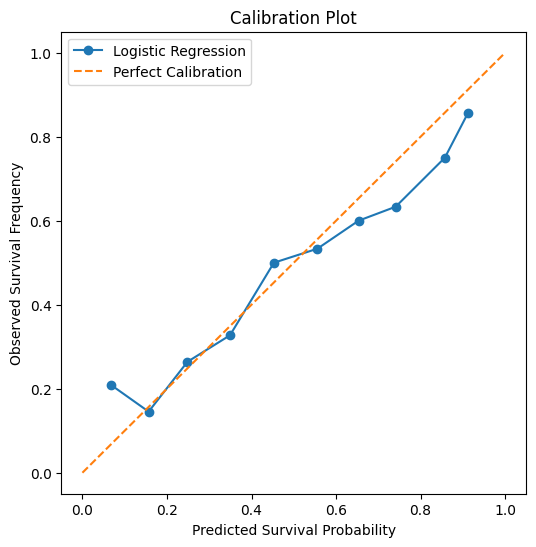

In [92]:
plt.figure(figsize=(6,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Logistic Regression'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel("Predicted Survival Probability")
plt.ylabel("Observed Survival Frequency")
plt.title("Calibration Plot")
plt.legend()

plt.show()

### Interpretation

The calibration curve demonstrates that the predicted survival probabilities generated by the integrated clinical-genomic logistic regression model are generally well aligned with observed survival frequencies.

Across most probability ranges, the calibration curve closely follows the ideal diagonal reference line, indicating that predicted probabilities provide a reasonable estimate of actual patient outcomes.

Minor deviations are observed at higher probability ranges, where the model appears to slightly overestimate survival probability. However, the overall agreement between predicted and observed outcomes remains strong.

These findings suggest that the model not only distinguishes between survival groups effectively but also produces clinically meaningful probability estimates that may support risk-based decision making.

# Conclusions

This study developed and evaluated machine learning models for predicting breast cancer survival using integrated clinical and genomic data from the METABRIC cohort.

Exploratory analysis revealed substantial differences in both clinical characteristics and gene expression profiles between survival groups. Differential expression analysis identified several genes associated with patient outcomes, including GSK3B, JAK1, CASP8, KMT2C, and HSD17B11, many of which are involved in cancer-related signaling pathways and tumor progression.

Three machine learning approaches—Logistic Regression, Random Forest, and Gradient Boosting—were evaluated using clinical features, genomic features, and an integrated feature set. Across all models, the combined clinical-genomic dataset consistently achieved the strongest predictive performance, demonstrating the value of integrating molecular information with traditional clinical variables.

The best-performing model was the combined Logistic Regression model, which achieved a ROC-AUC of approximately 0.73. Model interpretation using feature importance analysis and SHAP values revealed that both established clinical predictors (age at diagnosis, Nottingham Prognostic Index, tumor size, lymph node involvement) and biologically relevant genes contributed substantially to survival prediction.

Risk stratification analysis further demonstrated the potential clinical utility of the model by separating patients into distinct risk groups with markedly different observed survival rates. Calibration analysis indicated that predicted survival probabilities were generally well aligned with observed outcomes, suggesting that the model produces meaningful probability estimates rather than merely binary classifications.

Overall, the results support the use of integrated clinical and genomic data for improving breast cancer survival prediction and highlight the importance of interpretable machine learning approaches in precision oncology.

# Limitations

Several limitations should be considered when interpreting the results of this study.

First, the analysis was performed using a single retrospective cohort (METABRIC), and external validation on independent breast cancer datasets was not conducted. Consequently, the generalizability of the findings to other patient populations remains uncertain.

Second, survival prediction was formulated as a binary classification problem using overall survival status. This approach does not fully capture the temporal nature of patient outcomes and may overlook information contained in survival times.

Third, only a subset of genes was selected for machine learning modeling based on differential expression analysis. Although this strategy improves interpretability and reduces dimensionality, potentially important molecular signals may have been excluded.

Fourth, treatment-related variables available in the dataset were limited, and detailed information regarding therapeutic regimens, treatment response, and longitudinal follow-up was not incorporated into the predictive models.

Fifth, gene selection was performed prior to train-test splitting, which may introduce mild information leakage and slightly optimistic performance estimates.

Finally, while explainability techniques such as SHAP provide valuable insights into model behavior, they do not establish causal biological relationships between genes and patient outcomes. Experimental validation would be required to confirm the biological significance of identified predictors.

# Future Work

Several opportunities exist for extending this work.

Future studies could incorporate external validation cohorts to assess model robustness and generalizability across diverse patient populations. Additional molecular data types, including mutation profiles, copy number alterations, methylation data, and transcriptomic signatures, could also be integrated to improve predictive performance.

The current binary classification framework could be extended using survival analysis techniques such as Cox Proportional Hazards models, Random Survival Forests, or deep learning-based survival models. These approaches would enable direct modeling of survival time rather than survival status alone.

Further investigation of the identified prognostic genes may provide biological insights into mechanisms underlying breast cancer progression and treatment response. Integration of pathway-level analyses and network-based approaches could enhance biological interpretability.

Future studies could employ repeated cross-validation and external validation datasets to evaluate model stability and robustness.

Finally, future work could explore the development of clinical decision support tools that combine predictive modeling, risk stratification, and explainable artificial intelligence to support personalized treatment planning in oncology.